# 03 · Price elasticity by region — random slopes (pathmc / hierarchical)

**The decision.** We're setting regional prices. Elasticity — how much demand moves
when we change price — surely differs by region, but two traps lurk: (1) small
regions give noisy estimates we shouldn't over-trust, and (2) **price is endogenous**
— we historically cut prices *because* demand was soft, so a naive regression blames
low prices for low demand and understates elasticity.

We estimate a **partially-pooled random-slope** elasticity per region (noisy regions
borrow strength from the fleet), state exactly which confounders we're closing, and
then show honestly what partial pooling **can't** fix — an unobserved common demand
shock — which is the bridge to instrumental variables (notebook 11).

> The cookbook maps this to `pathmc` random slopes; here we fit the equivalent
> hierarchical model explicitly in PyMC so the shrinkage is fully visible. The
> identification logic (log-log demand, backdoor set) is unchanged.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pymc as pm
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 5

## 2 · Simulate a ground truth

A region × week panel with a **constant-elasticity (log-log) demand curve**
$\log Q_{rt} = \alpha_r + \beta_r \log P_{rt} + \gamma^\top Z_{rt} + \varepsilon_{rt}$,
where $\beta_r$ is region $r$'s true price elasticity (planted, varying around a
fleet mean of ≈ −1.4). Observed confounders $Z$ = competitor price, seasonality,
trend. We start with **no** endogeneity (`confounder_strength=0`) so we can first
show recovery, then switch it on in the caveats.


In [2]:
df, true_elast = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=0.0, seed=SEED)
df["log_price"] = np.log(df["price"]); df["log_demand"] = np.log(df["demand"])
regions = sorted(df["region"].unique()); R = len(regions)
r_idx = df["region"].map({r: i for i, r in enumerate(regions)}).values
print(f"{R} regions × {df['week'].nunique()} weeks; true fleet-mean elasticity {true_elast.mean():.2f}")
df.head()

12 regions × 80 weeks; true fleet-mean elasticity -1.42


,region,week,price,demand,competitor_price,season,trend,log_price,log_demand
0,region_00,0,13.971183,0.149926,18.083470,0.000000,0.00,2.636997,-1.897611
1,region_00,1,13.290969,0.202938,23.200038,0.071795,0.01,2.587085,-1.594857
2,region_00,2,13.003239,0.159630,20.405765,0.139417,0.02,2.565199,-1.834900
3,region_00,3,14.245949,0.157405,16.535730,0.198937,0.03,2.656473,-1.848934
4,region_00,4,14.025202,0.185275,19.832608,0.246895,0.04,2.640856,-1.685914


## 3 · Identify — elasticity as a random slope, and the backdoor set

**Estimand.** The per-region elasticity $\beta_r = \partial \log Q / \partial \log P$.
**Partial pooling** treats $\beta_r \sim \mathcal{N}(\mu_\beta, \tau_\beta^2)$ — noisy
regions shrink toward the fleet mean $\mu_\beta$, and $\tau_\beta$ *measures how much
elasticity genuinely varies*. Shrinkage is a feature: it stops us over-reacting to a
small region's noisy slope.

**Confounding is the crux.** Price is endogenous — a demand shock moves both $P$ and
$Q$. Conditioning on the **backdoor set** (competitor price, seasonality, trend)
closes the *observable* paths. What partial pooling does **not** fix is an
*unobserved* common shock — for that you need an instrument (notebook 11). We state
this assumption out loud rather than hide it.


## 4 · Estimate — hierarchical random-slope demand model

In [3]:
z = df[["competitor_price", "season", "trend"]].values
z = (z - z.mean(0)) / z.std(0)
lp = df["log_price"].values; ld = df["log_demand"].values

with pm.Model() as model:
    mu_beta = pm.Normal("mu_beta", -1.0, 1.0)              # fleet-mean elasticity
    tau_beta = pm.HalfNormal("tau_beta", 1.0)             # how much elasticity varies
    beta_r = pm.Normal("beta_r", mu_beta, tau_beta, shape=R)   # per-region slope (partial pooling)
    alpha_r = pm.Normal("alpha_r", 0, 5, shape=R)
    gamma = pm.Normal("gamma", 0, 2, shape=z.shape[1])
    sigma = pm.HalfNormal("sigma", 1.0)
    mu = alpha_r[r_idx] + beta_r[r_idx] * lp + z @ gamma
    pm.Normal("obs", mu=mu, sigma=sigma, observed=ld)
    idata = pm.sample(random_seed=SEED, progressbar=False, compute_convergence_checks=False, **FIT)

beta_post = idata.posterior["beta_r"].values.reshape(-1, R)
print(f"fleet-mean elasticity  {idata.posterior['mu_beta'].values.mean():.2f}  (true {true_elast.mean():.2f})")
print(f"between-region spread τ {idata.posterior['tau_beta'].values.mean():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_beta, tau_beta, beta_r, alpha_r, gamma, sigma]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 9 seconds.


fleet-mean elasticity  -1.43  (true -1.42)
between-region spread τ 0.24


## 5 · Validate — recover per-region elasticities & see the shrinkage

Estimated vs true elasticity per region should track the 45° line. The credible
intervals are wider for noisier regions, and their point estimates are pulled toward
the fleet mean — that's partial pooling protecting us from over-fitting thin data.


MAE vs truth — no pooling 0.46, partial pooling 0.16


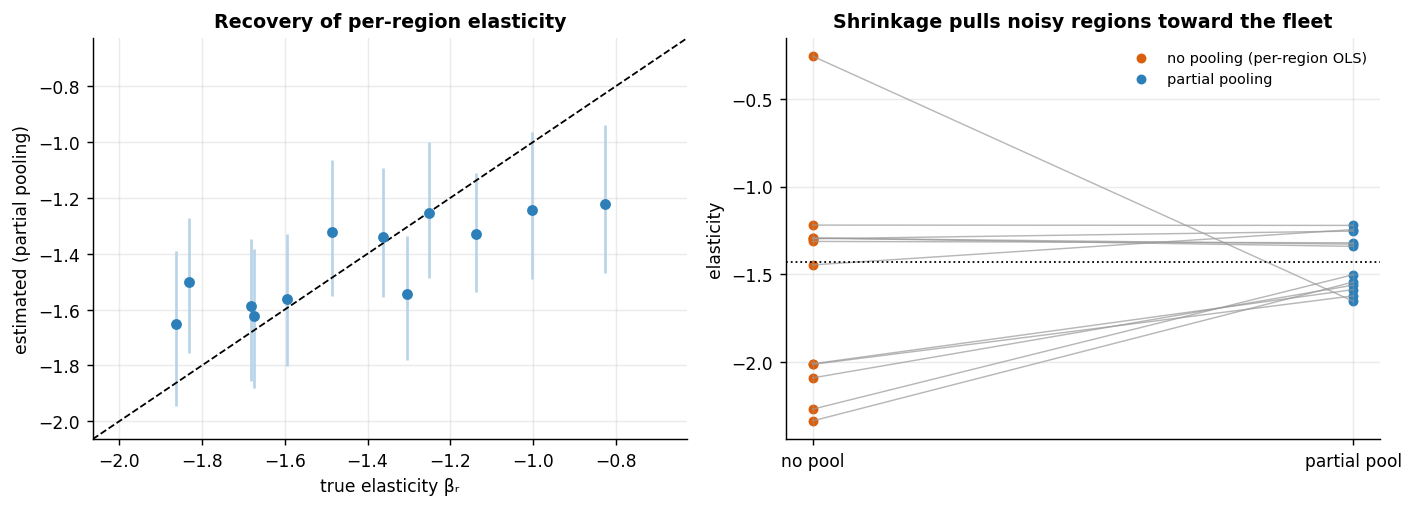

In [4]:
est_mean = beta_post.mean(0)
est_lo, est_hi = np.quantile(beta_post, [0.05, 0.95], 0)
# no-pooling (per-region OLS) for the shrinkage comparison
nopool = np.array([np.polyfit(lp[r_idx==i], ld[r_idx==i], 1)[0] for i in range(R)])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].errorbar(true_elast, est_mean, yerr=[est_mean-est_lo, est_hi-est_mean],
               fmt="o", color=plots.BLUE, ecolor="#b9d4e8", ms=5)
lim=[min(true_elast.min(),est_mean.min())-.2, max(true_elast.max(),est_mean.max())+.2]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("true elasticity βᵣ"); ax[0].set_ylabel("estimated (partial pooling)")
ax[0].set_title("Recovery of per-region elasticity")
fleet = est_mean.mean()
for i in range(R):
    ax[1].plot([0,1],[nopool[i],est_mean[i]], color=plots.GREY, lw=0.8, alpha=0.7)
ax[1].scatter(np.zeros(R), nopool, color=plots.ORANGE, s=20, label="no pooling (per-region OLS)")
ax[1].scatter(np.ones(R), est_mean, color=plots.BLUE, s=20, label="partial pooling")
ax[1].axhline(fleet, color="k", ls=":", lw=1); ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["no pool","partial pool"])
ax[1].set_ylabel("elasticity"); ax[1].set_title("Shrinkage pulls noisy regions toward the fleet")
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
print(f"MAE vs truth — no pooling {np.abs(nopool-true_elast).mean():.2f}, "
      f"partial pooling {np.abs(est_mean-true_elast).mean():.2f}")

## 6 · Decide, in euros

Elasticity drives the profit-maximising price. For a constant-elasticity demand
curve with marginal cost $c$, the optimal markup is
$\frac{P}{P-c} = \frac{-\beta}{-\beta-1}$ (needs $\beta<-1$ to be finite). We compute
the implied optimal price move per region, and — the honest part — **route
low-confidence regions to a controlled price test** instead of acting on a shaky
slope.


In [5]:
MARGINAL_COST = 8.0   # € per unit
# regions where we're confident elasticity < -1 (demand elastic enough to price on)
p_elastic = (beta_post < -1).mean(0)
rows = []
for i in range(R):
    conf = p_elastic[i]
    action = "set price" if conf > 0.9 else ("controlled test" if conf > 0.5 else "hold / test")
    rows.append({"region": regions[i], "elasticity": round(est_mean[i],2),
                 "90% CI": f"[{est_lo[i]:.2f}, {est_hi[i]:.2f}]",
                 "P(elastic)": round(conf,2), "action": action})
pd.set_option("display.max_rows", 20)
pd.DataFrame(rows)

,region,elasticity,90% CI,P(elastic),action
0,region_00,-1.59,"[-1.85, -1.35]",1.00,set price
1,region_01,-1.65,"[-1.94, -1.39]",1.00,set price
2,region_02,-1.32,"[-1.55, -1.06]",0.99,set price
3,region_03,-1.25,"[-1.49, -1.00]",0.95,set price
4,region_04,-1.25,"[-1.49, -0.97]",0.93,set price
5,region_05,-1.34,"[-1.55, -1.09]",0.98,set price
6,region_06,-1.56,"[-1.80, -1.33]",1.00,set price
7,region_07,-1.62,"[-1.88, -1.38]",1.00,set price
8,region_08,-1.33,"[-1.54, -1.11]",0.99,set price
9,region_09,-1.22,"[-1.47, -0.94]",0.91,set price


## 7 · Caveats — what partial pooling does *not* fix

Partial pooling handles *noise*, not *bias*. If price is endogenous to an
**unobserved** demand shock, conditioning on observed $Z$ isn't enough and the
elasticity is biased toward zero. We demonstrate by turning the hidden shock on:


In [6]:
df2, true2 = dgp.price_panel(n_regions=12, n_weeks=80, confounder_strength=1.2, seed=SEED)
lp2 = np.log(df2["price"].values); ld2 = np.log(df2["demand"].values)
r2 = df2["region"].map({r:i for i,r in enumerate(regions)}).values
z2 = df2[["competitor_price","season","trend"]].values; z2=(z2-z2.mean(0))/z2.std(0)
with pm.Model():
    mb=pm.Normal("mb",-1,1); tb=pm.HalfNormal("tb",1); br=pm.Normal("br",mb,tb,shape=R)
    ar=pm.Normal("ar",0,5,shape=R); g=pm.Normal("g",0,2,shape=3); s=pm.HalfNormal("s",1)
    pm.Normal("o", mu=ar[r2]+br[r2]*lp2+z2@g, sigma=s, observed=ld2)
    id2=pm.sample(draws=300,tune=300,chains=2,random_seed=SEED,progressbar=False,compute_convergence_checks=False)
biased = id2.posterior["br"].values.reshape(-1,R).mean(0)
print(f"clean regime    fleet elasticity {est_mean.mean():.2f}  (true {true_elast.mean():.2f})")
print(f"endogenous price fleet elasticity {biased.mean():.2f}  (true {true2.mean():.2f}) "
      f"→ biased toward zero by {biased.mean()-true2.mean():+.2f}")
print("\nFix = an instrument (a cost shifter) or a natural price experiment — see notebook 11 (IV).")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mb, tb, br, ar, g, s]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.


clean regime    fleet elasticity -1.43  (true -1.42)
endogenous price fleet elasticity -0.59  (true -1.42) → biased toward zero by +0.83

Fix = an instrument (a cost shifter) or a natural price experiment — see notebook 11 (IV).


**Other caveats.**
- **Log-log assumes constant elasticity** within region; if elasticity itself varies
  with price level, the single slope is a local approximation.
- **`lag(price)`** would capture dynamic carry-over (stockpiling); omitted here for
  clarity.
- **Shrinkage is a prior choice.** Very few regions, or a mis-specified $\tau_\beta$
  prior, can over-pool. Check the fleet-vs-region spread.
